# Import

In [1]:
library(dplyr)
library(magrittr)# pipe
library(moments)# skewness & kurtosis


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



## Funções de suporte

In [2]:
# Jupyter settings
options(repr.plot.width=9, repr.plot.height=5)

In [3]:
data_summary <- function(df){
    # Central tendency - mean, median
    ct1 <- sapply(df, mean)
    ct2 <- sapply(df, median)
    
    # Variability - std, coefficient of variation, min, max, range, skew, kurtosis
    d1 <- sapply(df, min)
    d2 <- sapply(df, max)
    d3 <- sapply(df, function(x){
        max(x)-min(x)
    })
    d4 <- sapply(df, function(x){
        n <- length(x)
        sqrt(var(x)*(n-1)/n)
    })
    d5 <- sapply(df, skewness)
    d6 <- sapply(df, kurtosis)
    d7 <- d4/ct1# cv
    
    # Concatenate
    s <- cbind(d1, d2, d3, ct1, ct2, d4, d7, d5, d6)
    colnames(s) <- c('min', 'max', 'range', 'mean', 'median', 'std', 'cv', 'skew', 'kurtosis')
    
    return(s)
}

## Importar dados

In [4]:
df_raw <- read.csv('../data/raw/ab_testing.csv')

# 1 Descrição dos dados

In [106]:
df1 <- df_raw

## 1.1 Renomear colunas

## 1.2 Dimensão dos dados

In [107]:
sprintf('Número de linhas: %d', nrow(df1))
sprintf('Número de colunas: %d', ncol(df1))

[1] "Número de linhas: 45883"

[1] "Número de colunas: 8"

## 1.3 Tratar os NAs

In [108]:
sapply(df1, function(x) any(is.na(x)))

uid   country    gender     spent purchases      date     group    device 
    FALSE     FALSE     FALSE     FALSE     FALSE     FALSE     FALSE     FALSE

## 1.4 Tipo dos dados

In [109]:
df1[['date']] <- as.POSIXct(df1[['date']], format='%Y-%m-%d')

In [110]:
str(df1)

'data.frame':	45883 obs. of  8 variables:
 $ uid      : int  11115722 11122053 11128688 11130578 11130759 11131070 11131381 11131664 11132813 11134390 ...
 $ country  : Factor w/ 10 levels "AUS","BRA","CAN",..: 8 10 10 10 5 10 7 9 10 4 ...
 $ gender   : Factor w/ 2 levels "F","M": 1 2 1 1 2 2 1 2 2 1 ...
 $ spent    : int  1595 498 2394 1197 1297 1796 2296 2293 698 498 ...
 $ purchases: int  5 2 6 3 3 4 4 7 2 2 ...
 $ date     : POSIXct, format: "2016-03-08" "2017-07-14" ...
 $ group    : Factor w/ 2 levels "GRP A","GRP B": 2 2 1 1 2 2 2 2 1 2 ...
 $ device   : Factor w/ 2 levels "A","I": 2 2 2 2 1 2 1 2 2 2 ...


## 1.5 Estatística descritiva

In [111]:
data_summary(df1[4:5])

,min,max,range,mean,median,std,cv,skew,kurtosis
spent,99,12170,12071,1883.453349,1596,1363.90668,0.7241521,1.365773,5.626945
purchases,1,30,29,4.544385,4,3.10242,0.6826931,1.348257,5.561924


# 2 EDA

## Data checkpoint

In [112]:
df2 <- df1

In [12]:
write.csv(df2,'../data/interim/c1_df2.csv', row.names=FALSE)

In [104]:
df2 <- read.csv('../data/interim/c1_df2.csv')

## 2.1 Homogeneidade dos grupos

### 2.1.1 Contagem dos grupos


    GRP A     GRP B 
0.5014711 0.4985289 

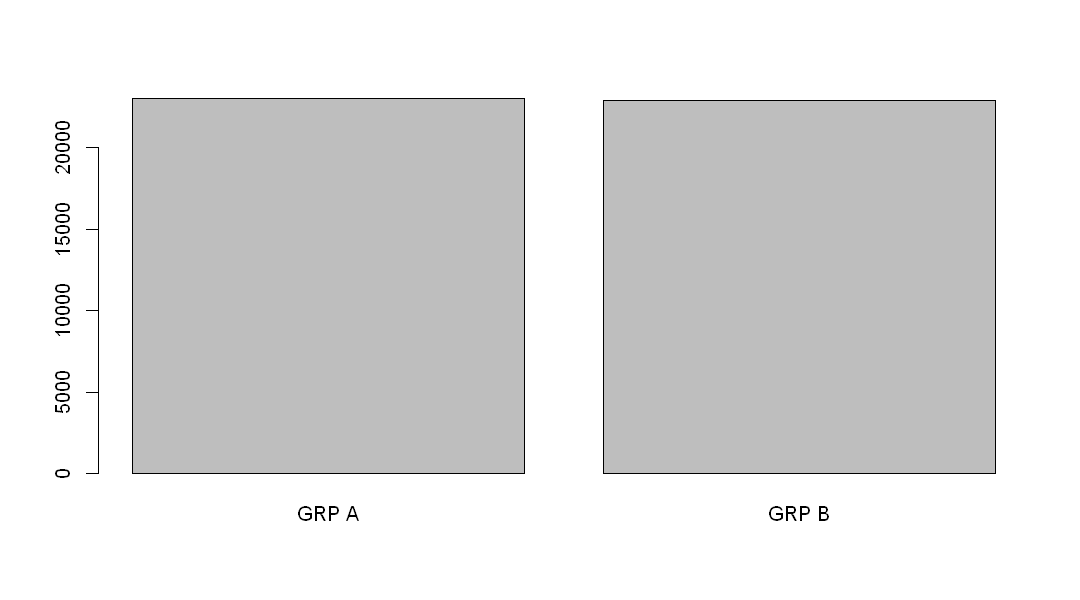

In [5]:
barplot(table(df2$group))
table(df2$group)/nrow(df2)

### 2.1.2 Country

In [113]:
grpa <- filter(df2, group=='GRP A')
grpb <- filter(df2, group=='GRP B')

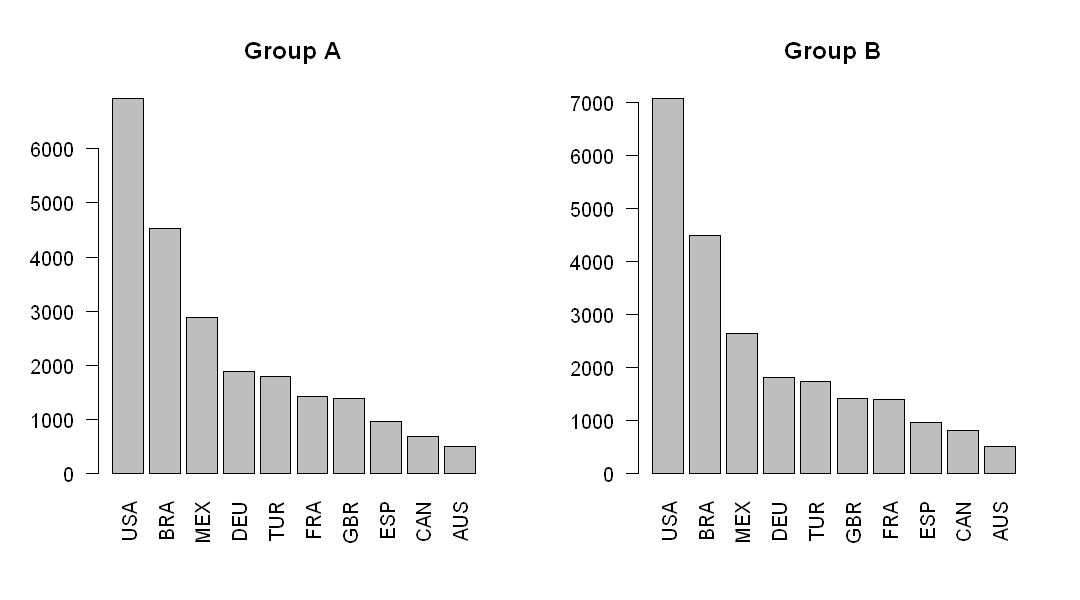

In [35]:
par(mfrow=c(1,2))
barplot(sort(table(grpa$country), decreasing=TRUE),
        main='Group A',
        las=2)
barplot(sort(table(grpb$country), decreasing=TRUE),
        main='Group B',
        las=2)

In [60]:
100*table(grpa$country)/nrow(grpa)


      AUS       BRA       CAN       DEU       ESP       FRA       GBR       MEX 
 2.199139 19.635795  3.033596  8.214177  4.215742  6.227998  6.023730 12.542918 
      TUR       USA 
 7.801295 30.105611 

In [61]:
100*table(grpb$country)/nrow(grpb)


      AUS       BRA       CAN       DEU       ESP       FRA       GBR       MEX 
 2.233977 19.633645  3.562997  7.895427  4.214392  6.159832  6.221037 11.550232 
      TUR       USA 
 7.615633 30.912827 

### 2.1.3 Gender

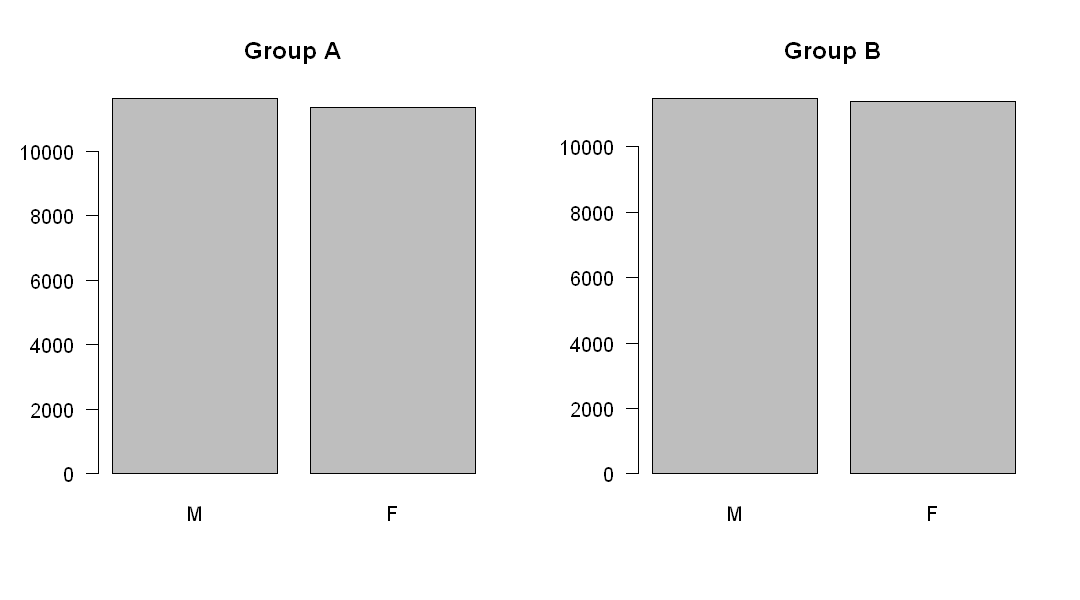

In [65]:
par(mfrow=c(1,2))
barplot(sort(table(grpa$gender), decreasing=TRUE),
        main='Group A',
        las=1)
barplot(sort(table(grpb$gender), decreasing=TRUE),
        main='Group B',
        las=1)

In [66]:
100*table(grpa$gender)/nrow(grpa)


       F        M 
49.41979 50.58021 

In [67]:
100*table(grpb$gender)/nrow(grpb)


       F        M 
49.82076 50.17924 

### 2.1.4 Spent

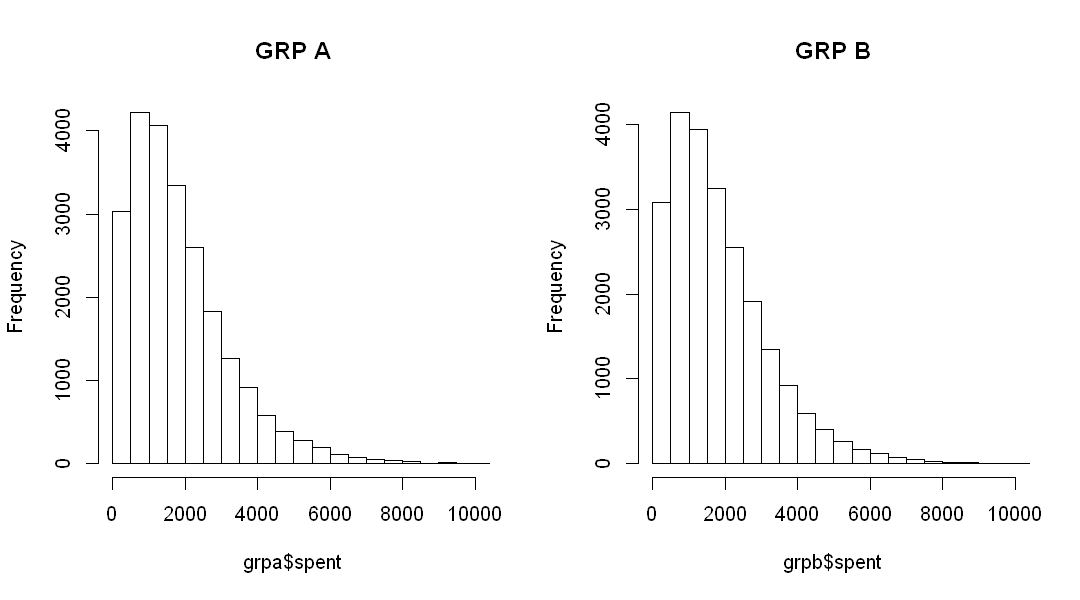

In [40]:
par(mfrow=c(1,2))
hist(grpa$spent,
     xlim=c(0,10000),
     breaks=20,
     main='GRP A')
hist(grpb$spent,
     xlim=c(0,10000),
     breaks=20,
     main='GRP B')

### 2.1.5 Purchases

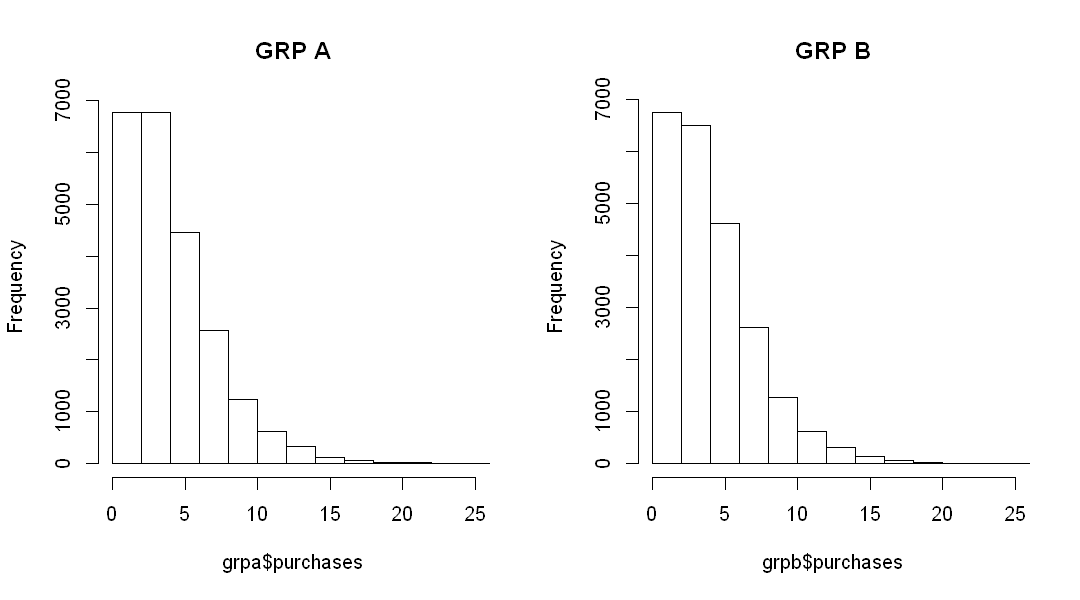

In [43]:
par(mfrow=c(1,2))
hist(grpa$purchases,
     xlim=c(0,25),
#      breaks=20,
     main='GRP A')
hist(grpb$purchases,
     xlim=c(0,25),
#      breaks=20,
     main='GRP B', col='')

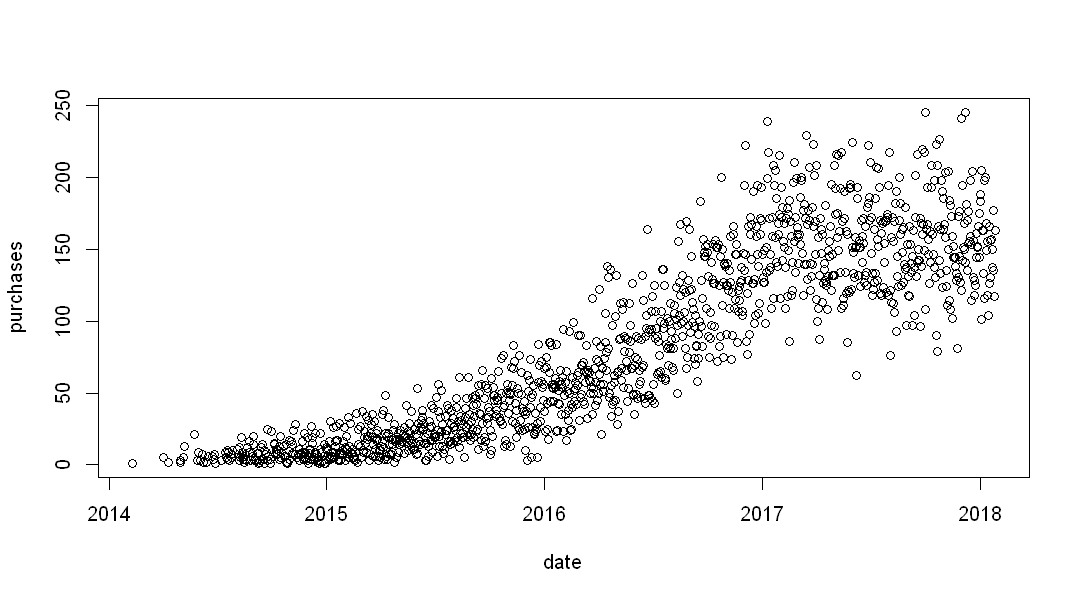

In [116]:
aux <- aggregate(purchases ~ date, data=grpa, FUN=sum)
plot(aux)

### 2.1.6 Date

### 2.1.7 Device